#Dependencies

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Optional, Tuple, Dict, Any, Union, List, Iterator
import math
from pathlib import Path
import json
from datetime import datetime
import logging
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
from torch.cuda.amp import GradScaler, autocast
from transformers import get_linear_schedule_with_warmup
from transformers import RobertaTokenizer, RobertaTokenizerFast, get_linear_schedule_with_warmup


#Model

In [ ]:
from dataclasses import dataclass

@dataclass
class SimpleLLMConfig:
    vocab_size: int = 50265
    hidden_size: int = 256#Embedding size
    num_hidden_layers: int = 6
    num_attention_heads: int = 8
    num_key_value_heads: int = 8
    head_dim: int = 32
    intermediate_size: int = 2048
    max_position_embeddings: int = 1014
    rope_theta: float = 10000.0
    rms_norm_eps: float = 1e-6
    attention_dropout: float = 0.1
    residual_dropout: float = 0.1
    use_qk_norm: bool = True
    enable_gradient_checkpointing: bool = True
    pad_token_id: int = 1
    use_gated_ffn: bool = True
    activation_fn: str = 'silu'
    latent_size: int = 256 # Changed to explicitly typed
    hidden_dim: int = 512 # Changed to explicitly typed

    num_experts_per_token: int = 1
    expert_specialization_metric: str = "cosine_similarity"
    load_imbalance_threshold: float = 0.3
    capacity_factor: float = 1.25
    auxiliary_loss_coef: float = 0.01
    track_expert_diversity: bool = True
    monitor_routing_entropy: bool = True
    analyze_latent_clustering: bool = True

    embed_dropout: float = 0.1
    ffn_dropout: float = 0.1 # Added missing ffn_dropout
    num_local_experts: int = 8

    max_seq_len: int = 1024

## Rotary Positionalembedding

In [ ]:
class ResearchRotaryEmbedding(nn.Module):
    """
     Rotary Embedding with proper memory optimization
    and support for variable sequence lengths, adapted for robust dimension handling.
    """

    def __init__(self, config):
        super().__init__()
        self.dim = config.head_dim # This must be EVEN for the current RoPE implementation
        self.theta = config.rope_theta
        self.max_seq_len = config.max_position_embeddings

        # Ensure head_dim is even for this RoPE implementation
        if self.dim % 2 != 0:
            raise ValueError(
                f"head_dim ({self.dim}) must be an even number for this ResearchRotaryEmbedding implementation. "
                "Please adjust your model configuration (e.g., latent_size or num_attention_heads).")

        # Precompute inverse frequencies for self.dim // 2
        inv_freq = 1.0 / (self.theta ** (torch.arange(0, self.dim, 2).float() / self.dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)

        # Cache for inference: Store [1, 1, seq_len, dim // 2]
        self.register_buffer("cached_cos", None, persistent=False)
        self.register_buffer("cached_sin", None, persistent=False)
        self.cached_seq_len = 0

    def _compute_cos_sin_for_rotation(self, seq_len, device, dtype):
        """
        Compute cos/sin values for rotation.
        Returns tensors of shape [1, 1, seq_len, self.dim // 2] for broadcasting.
        """
        # Use cache if available and suitable
        if (not self.training and
            self.cached_cos is not None and
            seq_len <= self.cached_seq_len):
            return self.cached_cos[:, :, :seq_len, :], self.cached_sin[:, :, :seq_len, :]

        # Compute on-the-fly
        t = torch.arange(seq_len, device=device, dtype=dtype)
        freqs = torch.outer(t, self.inv_freq.to(dtype))  # [seq_len, self.dim // 2]

        cos_vals = freqs.cos().unsqueeze(0).unsqueeze(0) # [1, 1, seq_len, dim // 2]
        sin_vals = freqs.sin().unsqueeze(0).unsqueeze(0) # [1, 1, seq_len, dim // 2]

        # Update cache for inference
        if not self.training and seq_len > self.cached_seq_len:
            self.cached_cos = cos_vals
            self.cached_sin = sin_vals
            self.cached_seq_len = seq_len
        elif self.training: # Clear cache during training
            self.cached_cos = None
            self.cached_sin = None
            self.cached_seq_len = 0

        return cos_vals, sin_vals

    def forward(self, x):
        """
        Args:
            x: Tensor of shape [batch_size, num_heads, seq_len, head_dim]
               or [batch_size, seq_len, num_heads, head_dim]
        """
        # Determine seq_len based on x's dimensions (assuming last two are seq_len, head_dim)
        seq_len = x.shape[-2]
        device = x.device
        dtype = x.dtype

        # Get cos/sin matrices, shape [1, 1, seq_len, self.dim // 2]
        cos, sin = self._compute_cos_sin_for_rotation(seq_len, device, dtype)

        # Split x into two halves, both will have self.dim // 2 features
        x1 = x[..., : self.dim // 2]
        x2 = x[..., self.dim // 2 :]

        # Apply rotary embedding (element-wise multiplication with broadcasting)
        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x1 * sin + x2 * cos

        return torch.cat((rotated_x1, rotated_x2), dim=-1)


## RMSN

In [ ]:
import torch
import torch.nn as nn

class ResearchRMSNorm(nn.Module):
    """
    Enhanced RMSNorm for research with proper initialization,
    numerical stability, and research-friendly features.

    Key improvements for research:
    1. Proper weight initialization
    2. Better numerical stability
    3. Optional elementwise affine (for ablation studies)
    4. Gradient checking
    """
    def __init__(self, hidden_size, eps=1e-6, elementwise_affine=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.eps = eps
        self.elementwise_affine = elementwise_affine

        if self.elementwise_affine:
            self.weight = nn.Parameter(torch.ones(hidden_size))
        else:
            self.register_parameter('weight', None)

        # Research: track normalization statistics
        self.register_buffer('running_rms', None)
        self.track_stats = False

        self._init_weights()

    def _init_weights(self):
        """Proper initialization for stability"""
        if self.elementwise_affine:
            # Xavier uniform for the scale parameter
            nn.init.constant_(self.weight, 1.0)

    def forward(self, x):
        """
        Enhanced forward pass with research features.

        Args:
            x (Tensor): Input of shape (..., hidden_size)

        Returns:
            Tensor: Normalized output of same shape as input.
        """
        original_dtype = x.dtype

        # Use float32 for stability during training
        if self.training:
            x = x.float()

        # Compute RMS - more numerically stable version
        mean_squares = x.pow(2).mean(dim=-1, keepdim=True)
        rms = torch.rsqrt(mean_squares + self.eps)

        # Normalize
        output = x * rms

        # Apply learned scale if enabled
        if self.elementwise_affine:
            output = output * self.weight

        # Track statistics for research analysis
        if self.track_stats and self.training:
            self._update_running_stats(mean_squares.detach())

        return output.to(original_dtype)

    def _update_running_stats(self, mean_squares):
        """Track running statistics for analysis"""
        if self.running_rms is None:
            self.running_rms = mean_squares.mean().item()
        else:
            self.running_rms = 0.99 * self.running_rms + 0.01 * mean_squares.mean().item()

    def extra_repr(self):
        """Enhanced representation for debugging"""
        return f"hidden_size={self.hidden_size}, eps={self.eps}, elementwise_affine={self.elementwise_affine}"

##Gated proj

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from typing import Optional

class ResearchGroupedQueryAttention(nn.Module):
    """
     Grouped Query Attention
    - Only causal masking (for decoder)
    - Padding mask handled externally via tokenizer
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.num_heads = config.num_attention_heads
        self.num_kv_heads = config.num_key_value_heads
        self.head_dim = config.head_dim

        # Validate dimensions
        assert self.hidden_size % self.num_heads == 0
        assert self.num_heads % self.num_kv_heads == 0

        self.n_rep = self.num_heads // self.num_kv_heads

        # Projection layers
        self.q_proj = nn.Linear(self.hidden_size, self.num_heads * self.head_dim, bias=False)
        self.k_proj = nn.Linear(self.hidden_size, self.num_kv_heads * self.head_dim, bias=False)
        self.v_proj = nn.Linear(self.hidden_size, self.num_kv_heads * self.head_dim, bias=False)
        self.o_proj = nn.Linear(self.num_heads * self.head_dim, self.hidden_size, bias=False)

        # Dropout
        self.attn_dropout = nn.Dropout(config.attention_dropout)
        self.resid_dropout = nn.Dropout(config.residual_dropout)

        # Research components
        self.rotary_emb = ResearchRotaryEmbedding(config)

        # Optional QK normalization
        self.use_qk_norm = getattr(config, 'use_qk_norm', False)
        if self.use_qk_norm:
            self.q_norm = ResearchRMSNorm(self.head_dim, eps=config.rms_norm_eps)
            self.k_norm = ResearchRMSNorm(self.head_dim, eps=config.rms_norm_eps)

    def forward(self,
                x: torch.Tensor,
                attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Forward pass with causal masking only
        - attention_mask: from tokenizer [batch_size, seq_len] (1=keep, 0=mask)
        """
        batch_size, seq_len, _ = x.shape
        device = x.device

        # Project queries, keys, values
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # Reshape to separate heads
        q = q.view(batch_size, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch_size, seq_len, self.num_kv_heads, self.head_dim)
        v = v.view(batch_size, seq_len, self.num_kv_heads, self.head_dim)

        # Apply QK normalization if enabled
        if self.use_qk_norm:
            q = self.q_norm(q)
            k = self.k_norm(k)

        # Apply rotary positional embeddings
        q = self.rotary_emb(q)
        k = self.rotary_emb(k)

        # Repeat k and v for grouped query attention
        k = k.repeat_interleave(self.n_rep, dim=2)
        v = v.repeat_interleave(self.n_rep, dim=2)

        # Transpose for attention computation
        q = q.transpose(1, 2)  # [batch, num_heads, seq_len, head_dim]
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Compute attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Apply causal mask (always for decoder)
        causal_mask = self._create_causal_mask(seq_len, device, scores.dtype)
        scores = scores + causal_mask

        # Apply padding mask from tokenizer if provided
        if attention_mask is not None:
            # Convert [batch_size, seq_len] to attention format
            # 1 = keep, 0 = mask -> we need 0 = keep, -inf = mask
            padding_mask = (1.0 - attention_mask.unsqueeze(1).unsqueeze(1)) * torch.finfo(scores.dtype).min
            scores = scores + padding_mask

        # Softmax and dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)

        # Apply attention to values
        attn_output = torch.matmul(attn_weights, v)

        # Transpose back and combine heads
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.num_heads * self.head_dim)

        # Final projection and dropout
        output = self.o_proj(attn_output)
        output = self.resid_dropout(output)

        return output

    def _create_causal_mask(self, seq_len: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        """Simple causal mask for autoregressive training"""
        mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        mask = mask * torch.finfo(dtype).min  # Convert to -inf where mask is True
        return mask.unsqueeze(0).unsqueeze(0)  # [1, 1, seq_len, seq_len]

## Feed Forward Network

In [ ]:
class ResearchFeedForwardNetwork(nn.Module):
    """
    Research-grade Feed Forward Network
    - Multiple activation options
    - Gated linear units
    - Research monitoring
    """

    def __init__(self, config):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.ffn_dim = getattr(config, 'ffn_dim', config.hidden_size * 4)

        # Gated FFN (like LLaMA)
        self.use_gated_ffn = getattr(config, 'use_gated_ffn', True)

        if self.use_gated_ffn:
            self.gate_proj = nn.Linear(self.hidden_size, self.ffn_dim, bias=False)
            self.up_proj = nn.Linear(self.hidden_size, self.ffn_dim, bias=False)
        else:
            # Standard FFN
            self.fc1 = nn.Linear(self.hidden_size, self.ffn_dim, bias=False)

        self.down_proj = nn.Linear(self.ffn_dim, self.hidden_size, bias=False)

        # Activation function
        self.act_fn = self._get_activation_fn(getattr(config, 'activation_fn', 'silu'))

        # Dropout
        self.dropout = nn.Dropout(config.ffn_dropout)

        # Research monitoring
        self.register_buffer('activation_mean', torch.zeros(1))

    def _get_activation_fn(self, activation_fn: str):
        """Get activation function for research"""
        if activation_fn == "silu":
            return F.silu
        elif activation_fn == "gelu":
            return F.gelu
        elif activation_fn == "relu":
            return F.relu
        else:
            raise ValueError(f"Unsupported activation: {activation_fn}")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.use_gated_ffn:
            # Gated FFN: gate * up -> activation -> down
            gate = self.gate_proj(x)
            up = self.up_proj(x)
            hidden = self.act_fn(gate) * up
        else:
            # Standard FFN: fc1 -> activation -> down
            hidden = self.fc1(x)
            hidden = self.act_fn(hidden)

        # Research: track activation statistics
        if not self.training:
            self.activation_mean = 0.99 * self.activation_mean + 0.01 * hidden.mean().item()

        hidden = self.dropout(hidden)
        output = self.down_proj(hidden)

        return output

    def get_research_metrics(self) -> Dict[str, torch.Tensor]:
        return {'activation_mean': self.activation_mean.item()}

##  Transformer

In [ ]:
import torch
import torch.nn as nn
from typing import Optional, Dict

class ResearchTransformerBlock(nn.Module):
    """
    Research-grade Transformer Block with enhanced features
    - Pre-norm architecture
    - Gated residual connections
    - Research monitoring
    - Flexible configurations
    """

    def __init__(self, config, layer_id: int = 0, use_moe: bool = False):
        super().__init__()
        self.config = config
        self.layer_id = layer_id
        self.use_moe = use_moe

        # Input normalization
        self.input_norm = ResearchRMSNorm(
            config.hidden_size,
            eps=config.rms_norm_eps,
            elementwise_affine=True
        )

        # Attention layer
        self.attention = ResearchGroupedQueryAttention(config)

        # Post-attention normalization
        self.post_attention_norm = ResearchRMSNorm(
            config.hidden_size,
            eps=config.rms_norm_eps,
            elementwise_affine=True
        )

        # Feed Forward Network or MoE
        if self.use_moe:
            self.ffn = AdvancedMoE(config) # Assuming AdvancedMoE takes config
        else:
            self.ffn = ResearchFeedForwardNetwork(config)

        # Dropout
        self.residual_dropout = nn.Dropout(config.residual_dropout)

        # Research: Gated residual connections
        self.use_gated_residual = getattr(config, 'use_gated_residual', False)
        if self.use_gated_residual:
            self.attn_gate = nn.Parameter(torch.ones(1))
            self.ffn_gate = nn.Parameter(torch.ones(1))

        # Research: Layer monitoring
        self.attention_output = None
        self.ffn_output = None
        self.register_buffer('grad_norm', torch.zeros(1))

    def forward(self, x: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Forward pass with research monitoring
        """
        # Store input for residual
        residual = x

        # Pre-norm attention
        x_norm = self.input_norm(x)
        attn_output = self.attention(x_norm, attention_mask)

        # Gated residual connection for attention
        if self.use_gated_residual:
            attn_output = attn_output * self.attn_gate

        x = residual + self.residual_dropout(attn_output)

        # Store for research
        self.attention_output = attn_output.detach() if not self.training else None

        # Pre-norm FFN or MoE
        residual = x
        x_norm = self.post_attention_norm(x)

        if self.use_moe:
            # AdvancedMoE returns output, casual_latent, fine_latent, analytics
            ffn_output, _, _, _ = self.ffn(x_norm)
        else:
            ffn_output = self.ffn(x_norm)

        # Gated residual connection for FFN
        if self.use_gated_residual:
            ffn_output = ffn_output * self.ffn_gate

        x = residual + self.residual_dropout(ffn_output)

        # Store for research
        self.ffn_output = ffn_output.detach() if not self.training else None

        return x

    def get_research_metrics(self) -> Dict[str, torch.Tensor]:
        """Get research metrics for this block"""
        metrics = {
            'layer_id': self.layer_id,
            'grad_norm': self.grad_norm.item(),
        }

        if self.attention_output is not None:
            metrics.update({
                'attention_output_norm': self.attention_output.norm().item(),
                'ffn_output_norm': self.ffn_output.norm().item() if self.ffn_output is not None else 0.0,
            })

        if self.use_gated_residual:
            metrics.update({
                'attn_gate': self.attn_gate.item(),
                'ffn_gate': self.ffn_gate.item(),
            })


        return metrics

## MultilayerTransformer

In [ ]:
class MultilayerResearchTransformer(nn.Module):
    """
    Complete multilayer transformer for research
    - Stacked transformer blocks only (no embeddings)
    - Research monitoring across layers
    - Flexible depth and configurations
    """

    def __init__(self, config, use_moe: bool = False):
        super().__init__()
        self.config = config
        self.hidden_size = config.hidden_size
        self.num_layers = config.num_hidden_layers
        self.use_moe = use_moe

        # No input/output embeddings - expecting pre-computed embeddings
        # Output normalization
        self.final_norm = ResearchRMSNorm(config.hidden_size, eps=config.rms_norm_eps)

        # Create transformer blocks only
        self.layers = nn.ModuleList([
            ResearchTransformerBlock(config, layer_id=i, use_moe=self.use_moe)
            for i in range(self.num_layers)
        ])

        # Research: gradient monitoring
        self.register_buffer('total_grad_norm', torch.zeros(1))

        # Initialize weights
        self.apply(self._init_weights)

    def _init_weights(self, module):
        """Research-grade weight initialization"""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, ResearchRMSNorm) and module.elementwise_affine:
            torch.nn.init.ones_(module.weight)

    def forward(self,
                x: torch.Tensor,
                attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        Forward pass for transformer layers only
        Expects pre-embedded input: [batch_size, seq_len, hidden_size]
        """
        # Apply all transformer blocks
        for layer in self.layers:
            x = layer(x, attention_mask)

        # Final normalization
        x = self.final_norm(x)

        return x

    def get_research_metrics(self) -> Dict[str, torch.Tensor]:
        """Get comprehensive research metrics from all layers"""
        metrics = {
            'total_grad_norm': self.total_grad_norm.item(),
            'num_layers': self.num_layers,
        }

        # Aggregate metrics from all layers
        for i, layer in enumerate(self.layers):
            layer_metrics = layer.get_research_metrics()
            for key, value in layer_metrics.items():
                metrics[f'layer_{i}_{key}'] = value

        return metrics

    def gradient_norm(self):
        """Compute total gradient norm for research"""
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        total_norm = total_norm ** 0.5
        self.total_grad_norm = torch.tensor(total_norm)
        return total_norm

    def count_parameters(self) -> Dict[str, int]:
        """Count parameters for research analysis - ONLY TRANSFORMER LAYERS"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)

        # Count attention and FFN parameters per layer
        attention_params = 0
        ffn_params = 0
        normalization_params = 0

        for layer in self.layers:
            # Count attention parameters
            attention_params += sum(p.numel() for p in layer.attention.parameters())
            # Count FFN parameters
            ffn_params += sum(p.numel() for p in layer.ffn.parameters())
            # Count normalization parameters
            normalization_params += sum(p.numel() for p in layer.input_norm.parameters())
            normalization_params += sum(p.numel() for p in layer.post_attention_norm.parameters())

        # Add final norm parameters
        normalization_params += sum(p.numel() for p in self.final_norm.parameters())

        return {
            'total_parameters': total_params,
            'trainable_parameters': trainable_params,
            'attention_parameters': attention_params,
            'ffn_parameters': ffn_params,
            'normalization_parameters': normalization_params,
            'parameters_per_layer': total_params // self.num_layers,
        }

    def get_layer_parameters(self, layer_id: int) -> Dict[str, int]:
        """Get parameter count for a specific layer"""
        if layer_id < 0 or layer_id >= len(self.layers):
            raise ValueError(f"Layer ID {layer_id} out of range")

        layer = self.layers[layer_id]

        attention_params = sum(p.numel() for p in layer.attention.parameters())
        ffn_params = sum(p.numel() for p in layer.ffn.parameters())
        norm_params = sum(p.numel() for p in layer.input_norm.parameters()) + \
                     sum(p.numel() for p in layer.post_attention_norm.parameters())

        return {
            'layer_id': layer_id,
            'total_parameters': attention_params + ffn_params + norm_params,
            'attention_parameters': attention_params,
            'ffn_parameters': ffn_params,
            'normalization_parameters': norm_params,
        }

## Embedding

In [ ]:
class ResearchEmbeddingLayer(nn.Module):
    """Research-grade embedding layer with advanced features"""
    def __init__(self, vocab_size: int, hidden_size: int, config):
        super().__init__()
        self.config = config
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size

        # Core embeddings
        self.token_embedding = nn.Embedding(vocab_size, hidden_size, padding_idx=1)

        # Research components
        # self.embed_norm = ResearchRMSNorm(hidden_dim, eps=config.rms_norm_eps) # Commented out RMSNorm
        self.dropout = nn.Dropout(config.embed_dropout)
        self.scale = math.sqrt(hidden_size)

        # Research monitoring
        self.register_buffer('embedding_norm_mean', torch.zeros(1))
        self.register_buffer('embedding_norm_std', torch.ones(1))
        self.register_buffer('embed_grad_norm', torch.zeros(1))

        self._init_embeddings()

    def _init_embeddings(self):
        """Research-grade initialization"""
        nn.init.normal_(self.token_embedding.weight, mean=0.0, std=0.02)
        if self.token_embedding.padding_idx is not None:
            with torch.no_grad():
                self.token_embedding.weight[self.token_embedding.padding_idx].zero_()

    def forward(self, input_ids: torch.Tensor) -> torch.Tensor:
        # Get embeddings and apply scaling
        embeddings = self.token_embedding(input_ids) * self.scale

        # Apply normalization - REMOVED
        # embeddings = self.embed_norm(embeddings)

        # Research: track statistics
        if not self.training:
            self._update_embedding_stats(embeddings.detach())

        return self.dropout(embeddings)

    def _update_embedding_stats(self, embeddings: torch.Tensor):
        """Update research statistics"""
        norms = embeddings.norm(dim=-1)
        self.embedding_norm_mean = 0.99 * self.embedding_norm_mean + 0.01 * norms.mean().item()
        self.embedding_norm_std = 0.99 * self.embedding_norm_std + 0.01 * norms.std().item()

    def get_research_metrics(self) -> Dict[str, torch.Tensor]:
        return {
            'embedding_norm_mean': self.embedding_norm_mean.item(),
            'embedding_norm_std': self.embedding_norm_std.item(),
            'embed_grad_norm': self.embed_grad_norm.item(),
        }

    def gradient_norm(self):
        if self.token_embedding.weight.grad is not None:
            grad_norm = self.token_embedding.weight.grad.norm().item()
            self.embed_grad_norm = torch.tensor(grad_norm)
            return grad_norm
        return 0.0

## output head

In [ ]:
class ResearchOutputHead(nn.Module):
    """Research-grade output head with advanced features"""
    def __init__(self, lattent_size: int, vocab_size: int, config,embed_weight: nn.Parameter=None):
        super().__init__()
        self.config = config
        self.lattent_size = lattent_size
        self.vocab_size = vocab_size

        # Research components
        self.norm = ResearchRMSNorm(lattent_size, eps=config.rms_norm_eps)
        self.head = nn.Linear(lattent_size, vocab_size, bias=False)

        # Weight tying
        if embed_weight is not None:
          self.head.weight = embed_weight

        # Research: temperature scaling
        self.temperature = nn.Parameter(torch.ones(1)) if getattr(config, 'learnable_temperature', False) else 1.0

        # Research monitoring
        self.register_buffer('logits_mean', torch.zeros(1))
        self.register_buffer('logits_std', torch.ones(1))
        self.register_buffer('head_grad_norm', torch.zeros(1))

    def forward(self, x: torch.Tensor, apply_softmax: bool = False) -> torch.Tensor:
        # Apply normalization

        x = self.norm(x)

        # Output projection with temperature
        logits = self.head(x) / self.temperature

        # Research: track statistics
        if not self.training:
            self._update_logit_stats(logits.detach())

        # Apply softmax if requested
        if apply_softmax:
            logits = F.softmax(logits, dim=-1)

        return logits

    def _update_logit_stats(self, logits: torch.Tensor):
        """Update research statistics"""
        self.logits_mean = 0.99 * self.logits_mean + 0.01 * logits.mean().item()
        self.logits_std = 0.99 * self.logits_std + 0.01 * logits.std().item()

    def get_research_metrics(self) -> Dict[str, torch.Tensor]:
        metrics = {
            'logits_mean': self.logits_mean.item(),
            'logits_std': self.logits_std.item(),
            'head_grad_norm': self.head_grad_norm.item(),
            'temperature': self.temperature.item() if isinstance(self.temperature, torch.Tensor) else self.temperature,
        }

        # Add norm statistics
        if hasattr(self.norm, 'get_research_metrics'):
            norm_metrics = self.norm.get_research_metrics()
            metrics.update({f'output_norm_{k}': v for k, v in norm_metrics.items()})

        return metrics

    def gradient_norm(self):
        """Compute gradient norm for research"""
        total_norm = 0.0
        for p in self.parameters():
            if p.grad is not None:
                total_norm += p.grad.norm().item() ** 2
        total_norm = total_norm ** 0.5
        self.head_grad_norm = torch.tensor(total_norm)
        return total_norm

    def get_logit_temperature(self) -> float:
        return self.temperature.item() if isinstance(self.temperature, torch.Tensor) else self.temperature

    def set_temperature(self, temperature: float):
        if isinstance(self.temperature, torch.Tensor):
            with torch.no_grad():
                self.temperature.fill_(temperature)
        else:
            self.temperature = temperature

## MOE



dependencies

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, Tuple, List, Optional
import pandas as pd
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

Configaration

expert_specialization_metric = "cosine_similarity" → This means we measure how different or unique each “expert” (specialist model component) is by checking how similar their outputs are. Cosine similarity is just a math way of saying “are two things pointing in the same direction?” If experts are too similar, they’re not really specialized.

load_imbalance_threshold = 0.3 → This sets a limit for how unevenly the workload can be spread among experts. If one expert is getting way more work than others (beyond 30% imbalance), that’s considered a problem.

capacity_factor = 1.25 → Think of this like giving each expert a “buffer” or extra room. If an expert can normally handle 100 tasks, with a factor of 1.25, it’s allowed to handle up to 125 before we say it’s overloaded.

auxiliary_loss_coef = 0.01 → This is a small penalty added during training to encourage fair use of experts. It’s like a gentle nudge telling the system: “Don’t let one expert hog all the work.”

In [ ]:
class ResearchMoEAnalyzer:
    """Comprehensive analysis toolkit for MoE research"""

    def __init__(self, config):
        self.config = config
        self.metrics_history = {
            'expert_load_balance': [],
            'routing_entropy': [],
            'expert_similarity': [],
            'latent_variance': [],
            'specialization_scores': []
        }

    def compute_expert_load_balance(self, expert_counts: torch.Tensor) -> Dict:
        """Compute Gini coefficient and other load balance metrics"""
        counts = expert_counts.float()
        total_tokens = counts.sum()

        # Gini coefficient for load imbalance
        sorted_counts, _ = torch.sort(counts)
        n = len(counts)
        index = torch.arange(1, n + 1, device=counts.device)
        gini = (torch.sum((2 * index - n - 1) * sorted_counts) /
                (n * torch.sum(sorted_counts) + 1e-8))

        # Load imbalance ratio
        max_load = counts.max()
        min_load = counts.min()
        imbalance_ratio = max_load / (min_load + 1e-8)

        # Expert utilization (percentage of experts used above threshold)
        utilization_threshold = total_tokens / (self.config.num_local_experts * 10)
        utilization_rate = (counts > utilization_threshold).float().mean()

        return {
            'gini_coefficient': gini.item(),
            'imbalance_ratio': imbalance_ratio.item(),
            'expert_utilization': utilization_rate.item(),
            'max_load': max_load.item(),
            'min_load': min_load.item()
        }

    def compute_routing_entropy(self, routing_logits: torch.Tensor) -> Dict:
        """Analyze routing decision diversity and uncertainty"""
        probs = torch.softmax(routing_logits, dim=-1)

        # Per-token entropy
        token_entropy = -torch.sum(probs * torch.log(probs + 1e-8), dim=-1)
        mean_entropy = token_entropy.mean()

        # Routing confidence (max probability)
        routing_confidence = probs.max(dim=-1)[0].mean()

        # Expert selection diversity
        expert_selections = probs.argmax(dim=-1)
        expert_diversity = torch.unique(expert_selections).numel() / self.config.num_local_experts

        return {
            'mean_routing_entropy': mean_entropy.item(),
            'routing_confidence': routing_confidence.item(),
            'expert_diversity': expert_diversity
        }

    def analyze_expert_specialization(self, expert_weights: torch.Tensor) -> Dict:
        """Analyze how specialized each expert is using weight analysis"""
        # Compute cosine similarity between expert weight matrices
        expert_weights_flat = expert_weights.view(self.config.num_local_experts, -1)
        similarities = torch.nn.functional.cosine_similarity(
            expert_weights_flat.unsqueeze(1),
            expert_weights_flat.unsqueeze(0),
            dim=-1
        )

        # Remove self-similarity
        mask = 1 - torch.eye(self.config.num_local_experts, device=expert_weights.device)
        mean_similarity = (similarities * mask).sum() / (mask.sum() + 1e-8)

        # Specialization score (1 - mean similarity with other experts)
        specialization_score = 1 - mean_similarity

        return {
            'mean_expert_similarity': mean_similarity.item(),
            'specialization_score': specialization_score.item(),
            'pairwise_similarities': similarities.cpu().numpy()
        }

    def analyze_latent_representations(self, casual_latent: torch.Tensor,
                                     fine_latent: torch.Tensor) -> Dict:
        """Comprehensive analysis of latent space properties"""

        # Variance analysis
        casual_variance = casual_latent.var(dim=-1).mean()
        fine_variance = fine_latent.var(dim=-1).mean()

        # Mutual information estimation (simplified)
        casual_entropy = torch.log(casual_latent.var(dim=0) + 1e-8).mean()
        fine_entropy = torch.log(fine_latent.var(dim=0) + 1e-8).mean()

        # Correlation between expert latents
        casual_flat = casual_latent.view(-1, casual_latent.size(-1))
        fine_flat = fine_latent.view(-1, fine_latent.size(-1))

        # Compute correlation matrix
        correlation = torch.corrcoef(torch.cat([casual_flat.T, fine_flat.T], dim=0))[:casual_flat.size(1), casual_flat.size(1):]
        mean_correlation = correlation.abs().mean()

        return {
            'casual_latent_variance': casual_variance.item(),
            'fine_latent_variance': fine_variance.item(),
            'casual_latent_entropy': casual_entropy.item(),
            'fine_latent_entropy': fine_entropy.item(),
            'expert_latent_correlation': mean_correlation.item(),
            'variance_ratio': (fine_variance / (casual_variance + 1e-8)).item()
        }

In [ ]:
class AdvancedMoE(nn.Module):
    """Research-grade MoE with comprehensive analytics"""

    def __init__(self, config, device=None):
        super().__init__()
        self.config = config
        self.device = device if device is not None else torch.device("cpu")
        self.analyzer = ResearchMoEAnalyzer(config)

        # Model components
        self.num_local_experts = config.num_local_experts
        self.hidden_dim = config.hidden_dim
        self.latent_size = config.latent_size

        self.router = nn.Linear(self.hidden_dim, self.num_local_experts, bias=False).to(self.device)
        self.experts = llmExpertsLatent(config, device=self.device)

        # Research tracking
        self.register_buffer("expert_load", torch.zeros(self.num_local_experts, device=self.device))
        self.register_buffer("expert_usage_count", torch.zeros(self.num_local_experts, device=self.device))
        self.load_alpha = 0.1

        # Store for analysis
        self._current_routing_logits = None
        self._current_expert_indices = None


    def forward(self, hidden_state) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, Dict]:
        """
        Enhanced forward pass with research analytics
        Returns:
            - output: [B, S, H] reconstructed hidden states
            - casual_latent: [B, S, L] generalist expert latents
            - fine_latent: [B, S, L] specialist expert latents
            - analytics: comprehensive research metrics
        """
        B, S, H = hidden_state.shape
        x = hidden_state.view(-1, H)
        # Router with load balancing
        logits = self.router(x)
        load_penalty = self.expert_load / (self.expert_load.sum() + 1e-6)
        adjusted_logits = logits - self.load_alpha * load_penalty.unsqueeze(0)

        # Store for analysis
        self._current_routing_logits = adjusted_logits.detach()

        # Expert selection
        _, fine_indices = torch.topk(adjusted_logits, k=self.config.num_experts_per_token, dim=-1)
        fine_indices = fine_indices.squeeze(-1)
        casual_indices = torch.zeros_like(fine_indices, device=self.device)

        self._current_expert_indices = fine_indices.detach()

        # Expert processing
        #casual_out, casual_latent = self.experts(x, casual_indices)
        casual_latent = self.experts(x, casual_indices)
        #fine_out, fine_latent = self.experts(x, fine_indices)
        fine_latent = self.experts(x, fine_indices)
        # Output fusion
        out = 0.5 * casual_latent + 0.5 * fine_latent

        # Update expert statistics
        if self.training:
            with torch.no_grad():
                counts = torch.bincount(fine_indices, minlength=self.num_local_experts).float()
                self.expert_load.mul_(0.9).add_(0.1 * counts)
                self.expert_usage_count += counts

        # Reshape outputs
        output = out.view(B, S, self.latent_size)
        casual_latent = casual_latent.view(B, S, self.latent_size)
        fine_latent = fine_latent.view(B, S, self.latent_size)

        # Compute comprehensive analytics
        analytics = self._compute_research_analytics(x, fine_indices, casual_latent, fine_latent)

        return output, casual_latent, fine_latent, analytics

    def _compute_research_analytics(self, x: torch.Tensor, fine_indices: torch.Tensor,
                                  casual_latent: torch.Tensor, fine_latent: torch.Tensor) -> Dict:
        """Compute comprehensive research metrics"""
        analytics = {}

        # Expert load balance analysis
        expert_counts = torch.bincount(fine_indices, minlength=self.num_local_experts)
        load_metrics = self.analyzer.compute_expert_load_balance(expert_counts)
        analytics.update(load_metrics)

        # Routing analysis
        if self._current_routing_logits is not None:
            routing_metrics = self.analyzer.compute_routing_entropy(self._current_routing_logits)
            analytics.update(routing_metrics)

        # Latent space analysis
        latent_metrics = self.analyzer.analyze_latent_representations(casual_latent, fine_latent)
        analytics.update(latent_metrics)

        # Expert specialization analysis (compute periodically for efficiency)
        if self.training and torch.rand(1) < 0.01:  # 1% chance per forward pass
            specialization_metrics = self.analyzer.analyze_expert_specialization(
                self.experts.gate_up_proj
            )
            analytics.update(specialization_metrics)

        return analytics

In [ ]:
class llmExpertsLatent(nn.Module):
    def __init__(self, config, device=None):
        super().__init__()
        self.config = config
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

        self.num_local_experts = config.num_local_experts
        self.intermediate_size = config.intermediate_size
        self.hidden_size = config.hidden_size
        self.hidden_dim = config.hidden_dim
        self.latent_size = config.latent_size


        # Expert weights with research-oriented initialization
        self.gate_up_proj = nn.Parameter(torch.empty(
            self.num_local_experts, self.hidden_dim, self.intermediate_size, device=self.device
        ))
        self.latent_proj = nn.Parameter(torch.empty(
            self.num_local_experts, self.intermediate_size, self.latent_size, device=self.device
        ))
        self.gate_down_proj = nn.Parameter(torch.empty(
            self.num_local_experts, self.latent_size, self.hidden_dim, device=self.device
        ))


        # Research-focused initialization
        self._initialize_expert_weights()

    def _initialize_expert_weights(self):
        """Research-oriented weight initialization for better expert specialization"""
        # Orthogonal initialization for better gradient flow
        for expert_idx in range(self.num_local_experts):
            nn.init.orthogonal_(self.gate_up_proj[expert_idx], gain=0.02)
            nn.init.orthogonal_(self.latent_proj[expert_idx], gain=0.02)
            nn.init.orthogonal_(self.gate_down_proj[expert_idx], gain=0.02)

    def forward(self, hidden_states, expert_indices) -> torch.Tensor:
        hidden_states = hidden_states.to(self.device)
        expert_indices = expert_indices.to(self.device)


        # Gather expert-specific weights
        up_proj = self.gate_up_proj[expert_indices]
        latent_proj = self.latent_proj[expert_indices]
        #down_proj = self.gate_down_proj[expert_indices]


        # Project with SiLU activation for better gradient flow
        intermediate = torch.bmm(hidden_states.unsqueeze(1), up_proj).squeeze(1)
        intermediate = nn.functional.silu(intermediate)

        # Latent projection (research bottleneck)
        latent = torch.bmm(intermediate.unsqueeze(1), latent_proj).squeeze(1)

        # Reconstruction with residual connection
        '''output = torch.bmm(latent.unsqueeze(1), down_proj).squeeze(1)
        output = output + hidden_states  # Residual connection'''

        return  latent


# Normal moe

In [ ]:
class NormalResearchLLM(nn.Module):
    """Normal Research LLM with attention and FFN"""
    def __init__(self, config):
        super().__init__()
        self.config = config

        # Embedding
        self.embedding = ResearchEmbeddingLayer(config.vocab_size, config.hidden_dim, config)

        # Transformer layers (normal)
        self.transformer = MultilayerResearchTransformer(config, use_moe=False)

        # Output head with weight tying
        self.output_head = ResearchOutputHead(
            config.hidden_dim,
            config.vocab_size,
            config, # Corrected: Pass the config object here

        )

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Get embeddings
        x = self.embedding(input_ids)

        # Apply transformer layers
        x = self.transformer(x, attention_mask)

        # Get logits
        return self.output_head(x)

In [ ]:
class MoEResearchLLM(nn.Module):
    """MoE Research LLM with attention and MoE layers in latent space"""
    def __init__(self, config):
        super().__init__()
        self.config = config


        self.embedding = ResearchEmbeddingLayer(config.vocab_size, config.hidden_dim, config)

        # MoE layer that processes embeddings into latent space
        self.moe_layer = AdvancedMoE(config)

        # Transformer layers work in latent space
        self.transformer = MultilayerResearchTransformer(config,use_moe=False)

        # Output head with weight tying (projects back from latent to vocab)
        self.output_head = ResearchOutputHead(
            config.latent_size,  # Changed from hidden_size to latent_size
            config.vocab_size,
            config
        )

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        # Get embeddings [B, S, H]
        x = self.embedding(input_ids)

        # Apply MoE to project to latent space [B, S, H] -> [B, S, L]
        moe_output, casual_latent, fine_latent, analytics = self.moe_layer(x)
        x = moe_output  # Now we work in latent dimension

        # Apply transformer layers in latent space [B, S, L] -> [B, S, L]
        x = self.transformer(x, attention_mask)

        # Get logits by projecting from latent space to vocab [B, S, L] -> [B, S, V]
        logits = self.output_head(x)

        return logits

# Train

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import time
import json
import os
from typing import Dict, List, Optional, Tuple
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import wandb

## Train config

In [ ]:
class ResearchTrainingConfig:
    """Updated configuration with RoBERTa tokenizer settings"""
    def __init__(self):

        self.batch_size = 16
        self.learning_rate = 3e-4
        self.weight_decay = 0.1
        self.warmup_steps = 1000
        self.total_steps = 50000
        self.max_seq_len = 512
        self.grad_clip = 1.0

        # Model parameters (must match RoBERTa tokenizer vocab size)
        self.vocab_size = 50265

        self.tokenizer_name = "roberta-base"

        # Experiment tracking
        self.log_interval = 100
        self.eval_interval = 1000
        self.save_interval = 5000
        self.checkpoint_dir = "checkpoints"

        # Mixed precision
        self.use_amp = True
        self.train_split = 0.9

## tokenizer

In [ ]:
class ResearchRobertaTokenizer:
    """RoBERTa tokenizer wrapper for research training"""

    def __init__(self, model_name: str = "roberta-base", max_length: int = 1024):
        try:
            # Try to load the fast tokenizer first (better performance)
            self.tokenizer = RobertaTokenizerFast.from_pretrained(model_name)
        except:
            # Fall back to regular tokenizer
            self.tokenizer = RobertaTokenizer.from_pretrained(model_name)

        self.max_length = max_length
        self.vocab_size = self.tokenizer.vocab_size
        self.pad_token_id = self.tokenizer.pad_token_id or self.tokenizer.eos_token_id

        print(f"✅ Loaded RoBERTa tokenizer with vocab size: {self.vocab_size}")
        print(f"📏 Max sequence length: {self.max_length}")

    def encode(self, text: str, add_special_tokens: bool = True) -> List[int]:
        """Encode text to token IDs"""
        return self.tokenizer.encode(
            text,
            max_length=self.max_length,
            truncation=True,
            add_special_tokens=add_special_tokens
        )

    def decode(self, token_ids: List[int], skip_special_tokens: bool = True) -> str:
        """Decode token IDs to text"""
        return self.tokenizer.decode(token_ids, skip_special_tokens=skip_special_tokens)

    def batch_encode(self, texts: List[str], add_special_tokens: bool = True) -> Dict[str, torch.Tensor]:
        """Batch encode texts for training"""
        return self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
            add_special_tokens=add_special_tokens
        )

    def get_vocab_size(self) -> int:
        return self.vocab_size

    def get_special_tokens(self) -> Dict[str, int]:
        """Get special tokens mapping"""
        return {
            'pad_token_id': self.pad_token_id,
            'bos_token_id': self.tokenizer.bos_token_id,
            'eos_token_id': self.tokenizer.eos_token_id,
            'unk_token_id': self.tokenizer.unk_token_id,
        }

## ResearchDataset

In [ ]:
class ResearchLanguageDataset(Dataset):
    """Improved dataset using RoBERTa tokenizer"""

    def __init__(self, texts: List[str], tokenizer: ResearchRobertaTokenizer, max_length: int = 1024):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Encode the text
        encoding = self.tokenizer.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0) # Get attention mask from tokenizer

        target_ids = input_ids.clone()
        target_ids[:-1] = input_ids[1:].clone()
        target_ids[-1] = self.tokenizer.pad_token_id

        return input_ids, attention_mask, target_ids

    @classmethod
    def create_attention_mask(cls, input_ids: torch.Tensor, pad_token_id: int) -> torch.Tensor:
        """Create attention mask from input IDs"""
        return (input_ids != pad_token_id).long()

## DataLoader

In [ ]:
class ResearchDataLoader:
    def __init__(self, dataset: ResearchLanguageDataset, batch_size: int, shuffle: bool = True):
        self.dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=4,
            pin_memory=True,
            drop_last=True,
            collate_fn=self._collate_fn  # ✅ ADD THIS for proper batching
        )

    def _collate_fn(self, batch):
        """Custom collate function to stack batches properly"""
        input_ids = torch.stack([item[0] for item in batch])
        attention_mask = torch.stack([item[1] for item in batch]) # Stack attention mask
        target_ids = torch.stack([item[2] for item in batch])
        return input_ids, attention_mask, target_ids # Return attention_mask

    def __iter__(self):
        return iter(self.dataloader)

    def __len__(self):
        return len(self.dataloader)

## Dtaloading

In [ ]:
def load_research_datasets(tokenizer: ResearchRobertaTokenizer, dataset_name: str = "wikitext", batch_size: int = 32):
    """Load research datasets compatible with ResearchLanguageDataset and ResearchDataLoader"""

    if dataset_name == "wikitext":
        return load_wikitext_dataset(tokenizer, batch_size)
    elif dataset_name == "c4":
        return load_c4_dataset(tokenizer, batch_size)


def load_wikitext_dataset(tokenizer: ResearchRobertaTokenizer, batch_size: int = 32):
    """Load WikiText dataset compatible with research classes"""
    try:
        from datasets import load_dataset

        print("📥 Loading WikiText-2 dataset...")
        dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

        # Filter out empty texts and clean
        train_texts = [text.strip() for text in dataset['train']['text'] if text.strip()]
        val_texts = [text.strip() for text in dataset['validation']['text'] if text.strip()]
        test_texts = [text.strip() for text in dataset['test']['text'] if text.strip()]

        print(f"📊 Loaded {len(train_texts)} training samples")
        print(f"📊 Loaded {len(val_texts)} validation samples")
        print(f"📊 Loaded {len(test_texts)} test samples")

        # Create ResearchLanguageDatasets
        train_dataset = ResearchLanguageDataset(train_texts, tokenizer, tokenizer.max_length)
        val_dataset = ResearchLanguageDataset(val_texts, tokenizer, tokenizer.max_length)
        test_dataset = ResearchLanguageDataset(test_texts, tokenizer, tokenizer.max_length)


        return train_dataset, val_dataset, test_dataset

    except ImportError:
        print("❌ datasets library not available. Using sample data.")
        return create_sample_data(tokenizer, batch_size)

def load_c4_dataset(tokenizer: ResearchRobertaTokenizer, batch_size: int = 32, num_samples: int = 10000):
    """Load C4 dataset compatible with research classes"""
    try:
        from datasets import load_dataset

        print("📥 Loading C4 dataset subset...")
        dataset = load_dataset("c4", "en", split=f"train[:{num_samples}]")

        texts = [example['text'].strip() for example in dataset if example['text'].strip()]

        # Split into train/val
        split_idx = int(len(texts) * 0.9)
        train_texts = texts[:split_idx]
        val_texts = texts[split_idx:]

        # Create ResearchLanguageDatasets
        train_dataset = ResearchLanguageDataset(train_texts, tokenizer, tokenizer.max_length)
        val_dataset = ResearchLanguageDataset(val_texts, tokenizer, tokenizer.max_length)


        return train_dataset, val_dataset, None

    except ImportError:
        print("❌ datasets library not available. Using sample data.")


# TRaining

In [ ]:
class ResearchTrainerWithRoberta:
    """Enhanced trainer with RoBERTa tokenizer - COMPLETE with training loop"""

    def __init__(self, model, config: ResearchTrainingConfig, model_type: str):
        self.model = model
        self.config = config
        self.model_type = model_type

        # Setup tokenizer
        self.tokenizer = ResearchRobertaTokenizer(config.tokenizer_name, config.max_seq_len)


        # Setup device
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.model.to(self.device)

        # Optimizer and scheduler
        self.optimizer = self._create_optimizer()
        self.scheduler = self._create_scheduler()

        # Loss function (ignore padding tokens)
        self.criterion = nn.CrossEntropyLoss(ignore_index=self.tokenizer.pad_token_id)

        # Mixed precision
        self.scaler = torch.cuda.amp.GradScaler() if config.use_amp and self.device.type == 'cuda' else None

        # Tracking
        self.step = 0
        self.best_loss = float('inf')
        self.metrics_history = {
            'train_loss': [], 'train_ppl': [], 'val_loss': [], 'val_ppl': [],
            'learning_rate': [], 'grad_norm': [], 'epoch': []
        }

        # Create checkpoint directory
        os.makedirs(config.checkpoint_dir, exist_ok=True)

        # Initialize wandb
        self._init_wandb()

        print(f"✅ Initialized {model_type} trainer with RoBERTa tokenizer")
        print(f"📚 Vocab size: {self.tokenizer.vocab_size}")



    def _create_optimizer(self):
        """Create optimizer with weight decay"""
        no_decay = ['bias', 'LayerNorm.weight']
        optimizer_grouped_parameters = [
            {
                'params': [p for n, p in self.model.named_parameters() if not any(nd in n for nd in no_decay)],
                'weight_decay': self.config.weight_decay,
            },
            {
                'params': [p for n, p in self.model.named_parameters() if any(nd in n for nd in no_decay)],
                'weight_decay': 0.0,
            },
        ]
        optimizer = optim.AdamW(optimizer_grouped_parameters, lr=self.config.learning_rate)
        return optimizer

    def _create_scheduler(self):
        """Create learning rate scheduler with warmup"""
        scheduler = get_linear_schedule_with_warmup(
            self.optimizer,
            num_warmup_steps=self.config.warmup_steps,
            num_training_steps=self.config.total_steps,
        )
        return scheduler

    def _init_wandb(self):
        """Initialize Weights & Biases for experiment tracking"""
        if wandb.run is None:
            wandb.init(project="research_llm_training", config=self.config.__dict__, settings=wandb.Settings(init_timeout=120))
            wandb.watch(self.model, log="all")


    def train(self, train_dataloader, val_dataloader=None, epochs: int = None):
        """
        MAIN TRAINING LOOP - This is where epochs happen!
        """
        epochs = epochs or (self.config.total_steps // len(train_dataloader)) + 1

        print(f"🚀 Starting training for {epochs} epochs")
        print(f"📊 Training samples: {len(train_dataloader.dataloader.dataset)}")
        print(f"📊 Validation samples: {len(val_dataloader.dataloader.dataset) if val_dataloader else 0}")

        # Load pre-trained weights if available
        self._load_pretrained_weights()

        for epoch in range(epochs):
            print(f"\n⏰ Epoch {epoch+1}/{epochs}")

            # Train for one epoch
            train_loss, train_ppl = self._train_epoch(train_dataloader, epoch)

            # Validate
            val_loss, val_ppl = self._validate_epoch(val_dataloader) if val_dataloader else (None, None)

            # Update metrics
            self.metrics_history['epoch'].append(epoch)
            self.metrics_history['train_loss'].append(train_loss)
            self.metrics_history['train_ppl'].append(train_ppl)
            if val_loss:
                self.metrics_history['val_loss'].append(val_loss)
                self.metrics_history['val_ppl'].append(val_ppl)

            # Save checkpoint
            self._save_checkpoint(epoch, train_loss, val_loss)

            # Early stopping check
            if self._check_early_stopping():
                print("🛑 Early stopping triggered!")
                break

        print("✅ Training completed!")
        return self.metrics_history

    def _train_epoch(self, train_dataloader, epoch: int):
        """Single training epoch"""
        self.model.train()
        total_loss = 0.0
        total_tokens = 0

        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1} Training")

        for batch_idx, (input_ids, attention_mask, target_ids) in enumerate(progress_bar): # Receive attention_mask
            # Move to device
            input_ids = input_ids.to(self.device)
            attention_mask = attention_mask.to(self.device) # Move attention_mask to device
            target_ids = target_ids.to(self.device)

            # Training step
            loss = self._training_step(input_ids, attention_mask, target_ids) # Pass attention_mask

            # Accumulate metrics
            batch_tokens = (input_ids != self.tokenizer.pad_token_id).sum().item()
            total_loss += loss * batch_tokens
            total_tokens += batch_tokens

            # Update progress bar
            current_loss = total_loss / total_tokens
            current_ppl = math.exp(current_loss)
            progress_bar.set_postfix({
                'loss': f'{current_loss:.4f}',
                'ppl': f'{current_ppl:.2f}',
                'lr': f'{self.scheduler.get_last_lr()[0]:.2e}'
            })

            # Step counter
            self.step += 1

            # Log to wandb
            if self.step % self.config.log_interval == 0:
                self._log_training_step(current_loss, current_ppl, batch_idx)

        # Calculate epoch metrics
        epoch_loss = total_loss / total_tokens
        epoch_ppl = math.exp(epoch_loss)

        print(f"📊 Epoch {epoch+1} - Train Loss: {epoch_loss:.4f}, PPL: {epoch_ppl:.2f}")

        return epoch_loss, epoch_ppl

    def _training_step(self, input_ids: torch.Tensor, attention_mask: torch.Tensor, target_ids: torch.Tensor) -> float: # Receive attention_mask
        """Single training step with forward/backward pass"""
        self.optimizer.zero_grad()

        # Mixed precision forward pass
        if self.scaler:
            with torch.cuda.amp.autocast():
                logits = self.model(input_ids, attention_mask) # Pass attention_mask
                loss = self.criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))

            # Backward pass with gradient scaling
            self.scaler.scale(loss).backward()  # Directly pass the loss for scaling
            self.scaler.unscale_(self.optimizer)

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)

            # Optimizer step
            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            # Standard forward pass
            logits = self.model(input_ids, attention_mask) # Pass attention_mask
            loss = self.criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))

            # Backward pass
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), self.config.grad_clip)

            # Optimizer step
            self.optimizer.step()

        # Scheduler step
        self.scheduler.step()

        return loss.item()

    def _validate_epoch(self, val_dataloader):
        """Validation epoch"""
        self.model.eval()
        total_loss = 0.0
        total_tokens = 0

        with torch.no_grad():
            for input_ids, attention_mask, target_ids in tqdm(val_dataloader, desc="Validation"): # Receive attention_mask
                input_ids = input_ids.to(self.device)
                attention_mask = attention_mask.to(self.device) # Move attention_mask to device
                target_ids = target_ids.to(self.device)

                # Forward pass
                if self.scaler:
                    with torch.cuda.amp.autocast():
                        logits = self.model(input_ids, attention_mask) # Pass attention_mask
                        loss = self.criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))
                else:
                    logits = self.model(input_ids, attention_mask) # Pass attention_mask
                    loss = self.criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))

                batch_tokens = (input_ids != self.tokenizer.pad_token_id).sum().item()
                total_loss += loss.item() * batch_tokens
                total_tokens += batch_tokens

        # Calculate validation metrics
        val_loss = total_loss / total_tokens
        val_ppl = math.exp(val_loss)

        print(f"📊 Validation - Loss: {val_loss:.4f}, PPL: {val_ppl:.2f}")

        self.model.train()
        return val_loss, val_ppl

    def _load_pretrained_weights(self):
        """Load pre-trained weights if available"""
        checkpoint_path = f"{self.config.checkpoint_dir}/{self.model_type}_best.pt"

        if os.path.exists(checkpoint_path):
            print(f"📥 Loading pre-trained weights from {checkpoint_path}")
            try:
                checkpoint = torch.load(checkpoint_path, map_location=self.device)

                # Load model state
                self.model.load_state_dict(checkpoint['model_state_dict'])

                # Load optimizer state (if compatible)
                if 'optimizer_state_dict' in checkpoint:
                    self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

                # Load scheduler state
                if 'scheduler_state_dict' in checkpoint:
                    self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

                # Load training state
                self.step = checkpoint.get('step', 0)
                self.best_loss = checkpoint.get('best_loss', float('inf'))
                self.metrics_history = checkpoint.get('metrics_history', self.metrics_history)

                print(f"✅ Successfully loaded checkpoint from step {self.step}")

            except Exception as e:
                print(f"❌ Error loading checkpoint: {e}")
                print("🆕 Starting training from scratch")
        else:
            print("🆕 No pre-trained weights found, starting from scratch")

    def _save_checkpoint(self, epoch: int, train_loss: float, val_loss: float = None):
        """Save model checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'step': self.step,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'best_loss': self.best_loss,
            'metrics_history': self.metrics_history,
            'config': self.config.__dict__,
        }

        if self.scaler:
            checkpoint['scaler_state_dict'] = self.scaler.state_dict()

        # Regular checkpoint
        checkpoint_path = f"{self.config.checkpoint_dir}/{self.model_type}_epoch_{epoch+1}.pt"
        torch.save(checkpoint, checkpoint_path)

        # Best model checkpoint
        if val_loss and val_loss < self.best_loss:
            self.best_loss = val_loss
            best_checkpoint_path = f"{self.config.checkpoint_dir}/{self.model_type}_best.pt"
            torch.save(checkpoint, best_checkpoint_path)
            print(f"🏆 New best model saved! Val Loss: {val_loss:.4f}")

        # Latest checkpoint (overwrites)
        latest_path = f"{self.config.checkpoint_dir}/{self.model_type}_latest.pt"
        torch.save(checkpoint, latest_path)

        print(f"💾 Checkpoint saved: {checkpoint_path}")

    def _log_training_step(self, loss: float, ppl: float, batch_idx: int):
        """Log training step to wandb"""
        current_lr = self.scheduler.get_last_lr()[0]
        grad_norm = self._get_gradient_norm()

        wandb.log({
            'step': self.step,
            'train/loss': loss,
            'train/ppl': ppl,
            'train/learning_rate': current_lr,
            'train/grad_norm': grad_norm,
            'train/batch': batch_idx,
        })

    def _get_gradient_norm(self):
        """Compute gradient norm for monitoring"""
        total_norm = 0.0
        for p in self.model.parameters():
            if p.grad is not None:
                param_norm = p.grad.data.norm(2)
                total_norm += param_norm.item() ** 2
        return total_norm ** 0.5

    def _check_early_stopping(self, patience: int = 5):
        """Check if training should stop early"""
        if len(self.metrics_history['val_loss']) < patience:
            return False

        # Check if validation loss hasn't improved for 'patience' epochs
        recent_losses = self.metrics_history['val_loss'][-patience:]
        return min(recent_losses) >= self.best_loss


## Training setup

In [ ]:
import wandb

wandb.login(key="2391a32e0cbb01006bb4bfb5f4b8f6b74f314114")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lakshmeeshan85 (lakshmeeshan85-visvesvaraya-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
def train_with_roberta_tokenizer():
    """Train models with RoBERTa tokenizer"""
    config = ResearchTrainingConfig()

    # Initialize tokenizer
    tokenizer = ResearchRobertaTokenizer(config.tokenizer_name, config.max_seq_len)

    # Load datasets
    print("📚 Loading research datasets...")
    train_dataset, val_dataset, test_dataset = load_research_datasets(tokenizer, "wikitext")

    # Create data loaders
    train_dataloader = ResearchDataLoader(train_dataset, config.batch_size, shuffle=True)
    val_dataloader = ResearchDataLoader(val_dataset, config.batch_size, shuffle=False)

    # Test tokenization
    print("\n🔤 Testing RoBERTa tokenization:")
    sample_text = "The quick brown fox jumps over the lazy dog."
    tokens = tokenizer.encode(sample_text)
    decoded = tokenizer.decode(tokens)

    print(f"Original: {sample_text}")
    print(f"Tokens: {tokens}")
    print(f"Decoded: {decoded}")
    print(f"Token count: {len(tokens)}")

    # Train Normal LLM
    print("\n🧪 Training Normal Research LLM with RoBERTa...")
    model_config = SimpleLLMConfig()
    model_config.hidden_size=256
    model_config.hidden_dim=256
    normal_model = NormalResearchLLM(model_config)
    normal_trainer = ResearchTrainerWithRoberta(normal_model, config, 'normal')
    normal_metrics = normal_trainer.train(train_dataloader, val_dataloader,5)



    return normal_trainer, normal_metrics

normal_trainer, normal_metrics  =train_with_roberta_tokenizer()


✅ Loaded RoBERTa tokenizer with vocab size: 50265
📏 Max sequence length: 512
📚 Loading research datasets...
📥 Loading WikiText-2 dataset...
📊 Loaded 23767 training samples
📊 Loaded 2461 validation samples
📊 Loaded 2891 test samples

🔤 Testing RoBERTa tokenization:
Original: The quick brown fox jumps over the lazy dog.
Tokens: [0, 133, 2119, 6219, 23602, 13855, 81, 5, 22414, 2335, 4, 2]
Decoded: The quick brown fox jumps over the lazy dog.
Token count: 12

🧪 Training Normal Research LLM with RoBERTa...
✅ Loaded RoBERTa tokenizer with vocab size: 50265
📏 Max sequence length: 512
✅ Initialized normal trainer with RoBERTa tokenizer
📚 Vocab size: 50265
🚀 Starting training for 5 epochs
📊 Training samples: 23767
📊 Validation samples: 2461
🆕 No pre-trained weights found, starting from scratch

⏰ Epoch 1/5


Epoch 1 Training: 100%|██████████| 1485/1485 [07:19<00:00,  3.38it/s, loss=6.9554, ppl=1048.75, lr=2.97e-04]


📊 Epoch 1 - Train Loss: 6.9554, PPL: 1048.75


Validation: 100%|██████████| 153/153 [00:18<00:00,  8.15it/s]


📊 Validation - Loss: 6.0084, PPL: 406.84
🏆 New best model saved! Val Loss: 6.0084
💾 Checkpoint saved: checkpoints/normal_epoch_1.pt

⏰ Epoch 2/5


...

📊 Validation - Loss: 5.3765, PPL: 216.27
🏆 New best model saved! Val Loss: 5.3765
💾 Checkpoint saved: checkpoints/normal_epoch_4.pt

⏰ Epoch 5/5


Epoch 5 Training: 100%|██████████| 1485/1485 [07:18<00:00,  3.39it/s, loss=4.1928, ppl=66.21, lr=2.61e-04]


📊 Epoch 5 - Train Loss: 4.1928, PPL: 66.21


Validation: 100%|██████████| 153/153 [00:18<00:00,  8.20it/s]


📊 Validation - Loss: 5.3625, PPL: 213.26
🏆 New best model saved! Val Loss: 5.3625
💾 Checkpoint saved: checkpoints/normal_epoch_5.pt
🛑 Early stopping triggered!
✅ Training completed!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Define the source and destination paths
source_path = '/content/wandb'
destination_path = '/content/drive/MyDrive/wandb_normal' # You can change this path

import os

# Check if the source directory exists
if not os.path.exists(source_path):
    print(f"Source directory '{source_path}' does not exist. Please ensure checkpoints were created.")
else:
    # Create the destination directory if it doesn't exist
    os.makedirs(destination_path, exist_ok=True)

    # Copy the contents of the directory
    # Using rsync for efficiency and better handling of existing files
    # The destination_path is now properly quoted to handle spaces
    !rsync -av --progress "{source_path}"/ "{destination_path}"
    print(f"Successfully copied checkpoints from '{source_path}' to '{destination_path}'")

sending incremental file list
./
debug-internal.log -> run-20251128_113705-iwo5a3ww/logs/debug-internal.log
debug.log -> run-20251128_113705-iwo5a3ww/logs/debug.log
latest-run -> run-20251128_113705-iwo5a3ww
run-20251128_113705-iwo5a3ww/
run-20251128_113705-iwo5a3ww/run-iwo5a3ww.wandb
      6,094,848 100%  107.06MB/s    0:00:00 (xfr#1, to-chk=10/16)
run-20251128_113705-iwo5a3ww/files/
run-20251128_113705-iwo5a3ww/files/output.log
          2,631 100%   47.58kB/s    0:00:00 (xfr#2, to-chk=6/16)
run-20251128_113705-iwo5a3ww/files/requirements.txt
         14,370 100%  259.87kB/s    0:00:00 (xfr#3, to-chk=5/16)
run-20251128_113705-iwo5a3ww/files/wandb-metadata.json
            911 100%   16.47kB/s    0:00:00 (xfr#4, to-chk=4/16)
run-20251128_113705-iwo5a3ww/logs/
run-20251128_113705-iwo5a3ww/logs/debug-core.log -> /root/.cache/wandb/logs/core-debug-20251128_113706.log
run-20251128_113705-iwo5a3ww/logs/debug-internal.log
            624 100%   11.08kB/s    0:00:00 (xfr#5, to-chk=2/16)
run-

In [ ]:
# Define the source and destination paths
source_path = '/content/checkpoints'
destination_path = '/content/drive/MyDrive/checkpoint_normal' # You can change this path

import os

# Check if the source directory exists
if not os.path.exists(source_path):
    print(f"Source directory '{source_path}' does not exist. Please ensure checkpoints were created.")
else:
    # Create the destination directory if it doesn't exist
    os.makedirs(destination_path, exist_ok=True)

    # Copy the contents of the directory
    # Using rsync for efficiency and better handling of existing files
    # The destination_path is now properly quoted to handle spaces
    !rsync -av --progress "{source_path}"/ "{destination_path}"
    print(f"Successfully copied checkpoints from '{source_path}' to '{destination_path}'")

sending incremental file list
./
normal_best.pt
    882,087,021 100%  126.29MB/s    0:00:06 (xfr#1, to-chk=6/8)
normal_epoch_1.pt
    882,087,808 100%   53.51MB/s    0:00:15 (xfr#2, to-chk=5/8)
normal_epoch_2.pt
    882,087,872 100%   42.99MB/s    0:00:19 (xfr#3, to-chk=4/8)
normal_epoch_3.pt
    882,087,936 100%   51.03MB/s    0:00:16 (xfr#4, to-chk=3/8)
normal_epoch_4.pt
    882,087,936 100%   61.09MB/s    0:00:13 (xfr#5, to-chk=2/8)
normal_epoch_5.pt
    882,088,000 100%   67.75MB/s    0:00:12 (xfr#6, to-chk=1/8)
normal_latest.pt
    882,087,695 100%   58.29MB/s    0:00:14 (xfr#7, to-chk=0/8)

sent 6,176,122,260 bytes  received 152 bytes  64,001,268.52 bytes/sec
total size is 6,174,614,268  speedup is 1.00
Successfully copied checkpoints from '/content/checkpoints' to '/content/drive/MyDrive/checkpoint_normal'


In [ ]:
 print(normal_metrics)

{'train_loss': [6.582012912626019, 5.104904774102259, 4.514892381815876, 4.085425540960822, 3.738215659515823], 'train_ppl': [721.9911726893278, 164.82837385441456, 91.36773266379689, 59.46723811333605, 42.02293999428449], 'val_loss': [5.856082034491784, 5.480605736433699, 5.3587900614186434, 5.34522106899123, 5.368955006594878], 'val_ppl': [349.352707295983, 239.9920352741728, 212.46771797632826, 209.60421647010455, 214.63845470005535], 'learning_rate': [], 'grad_norm': [], 'epoch': [0, 1, 2, 3, 4]}


In [ ]:
normal_trainer

In [ ]:
! pip install torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
model_config = SimpleLLMConfig()
model_config.hidden_size =256
model_config.hidden_dim = 256 # Ensure consistency with embedding layer output

In [ ]:
 model_config = SimpleLLMConfig()
model_config.hidden_size=256
model_config.hidden_dim=256
normal_model = NormalResearchLLM(model_config)

In [ ]:
summary(normal_model,
        input_size=[(1,model_config.max_seq_len), (1, model_config.max_seq_len)],
    dtypes=[torch.long, torch.long] )

Layer (type:depth-idx)                                       Output Shape              Param #
NormalResearchLLM                                            [1, 1024, 50265]          --
├─ResearchEmbeddingLayer: 1-1                                [1, 1024, 256]            --
│    └─Embedding: 2-1                                        [1, 1024, 256]            12,867,840
│    └─Dropout: 2-2                                          [1, 1024, 256]            --
├─MultilayerResearchTransformer: 1-2                         [1, 1024, 256]            --
│    └─ModuleList: 2-3                                       --                        --
│    │    └─ResearchTransformerBlock: 3-1                    [1, 1024, 256]            1,049,152
│    │    └─ResearchTransformerBlock: 3-2                    [1, 1024, 256]            1,049,152
│    │    └─ResearchTransformerBlock: 3-3                    [1, 1024, 256]            1,049,152
│    │    └─ResearchTransformerBlock: 3-4                    [1, 1

In [ ]:
summary(normal_llm,
        input_size=[(1,model_config.max_seq_len), (1, model_config.max_seq_len)],
    dtypes=[torch.long, torch.long] )

Layer (type:depth-idx)                                       Output Shape              Param #
NormalResearchLLM                                            [1, 1024, 50265]          --
├─ResearchEmbeddingLayer: 1-1                                [1, 1024, 512]            --
│    └─Embedding: 2-1                                        [1, 1024, 512]            25,735,680
│    └─Dropout: 2-2                                          [1, 1024, 512]            --
├─MultilayerResearchTransformer: 1-2                         [1, 1024, 512]            --
│    └─ModuleList: 2-3                                       --                        --
│    │    └─ResearchTransformerBlock: 3-1                    [1, 1024, 512]            3,671,104
│    │    └─ResearchTransformerBlock: 3-2                    [1, 1024, 512]            3,671,104
│    │    └─ResearchTransformerBlock: 3-3                    [1, 1024, 512]            3,671,104
│    │    └─ResearchTransformerBlock: 3-4                    [1, 1

In [ ]:
model_config = SimpleLLMConfig()
moe_model = MoEResearchLLM(model_config)

In [ ]:
summary(
    moe_model,
    input_size=[(1,model_config.max_seq_len), (1, model_config.max_seq_len)],  # batch_size=16
    dtypes=[torch.long, torch.long]  # both inputs are integer tensors
)

Layer (type:depth-idx)                                       Output Shape              Param #
MoEResearchLLM                                               [1, 1024, 50265]          --
├─ResearchEmbeddingLayer: 1-1                                [1, 1024, 512]            --
│    └─Embedding: 2-1                                        [1, 1024, 512]            25,735,680
│    └─Dropout: 2-2                                          [1, 1024, 512]            --
├─AdvancedMoE: 1-2                                           [1, 1024, 256]            --
│    └─Linear: 2-3                                           [1024, 8]                 4,096
│    └─llmExpertsLatent: 2-4                                 [1024, 256]               13,631,488
│    └─llmExpertsLatent: 2-5                                 [1024, 256]               (recursive)
├─MultilayerResearchTransformer: 1-3                         [1, 1024, 256]            --
│    └─ModuleList: 2-6                                       --    

In [ ]:
config = ResearchTrainingConfig()
tokenizer = ResearchRobertaTokenizer(config.tokenizer_name, config.max_seq_len)
train_dataset, val_dataset, test_dataset = load_research_datasets(tokenizer, "wikitext")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

📊 Loaded 23767 training samples
📊 Loaded 2461 validation samples
📊 Loaded 2891 test samples


In [ ]:
train_dataloader = ResearchDataLoader(train_dataset, config.batch_size, shuffle=True)
val_dataloader = ResearchDataLoader(val_dataset, config.batch_size, shuffle=False)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
batch = next(iter(train_dataloader))
input_ids, attention_mask, target_ids = batch

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
print(input_ids[1][0:10])

tensor([    0,  5214,  5457,  5457,  1785,     9, 12131,  5457,  5457,  5457])


In [ ]:
for i in range(input_ids.size(0)):  # iterate over batch dimension
    text = tokenizer.decode(input_ids[i].tolist(), skip_special_tokens=True)
    print(f"Sample {i}:\n{text}\n")


Sample 0:
XeO

Sample 1:
= = = Board of Directors = = =

Sample 2:
= = Influences and style = =

Sample 3:
= = Exploration = =

Sample 4:
The edibility of this species is questionable ; although Verpa bohemica is eaten by many , consumption of large amounts in a single sitting , or on successive days , has been reported to cause poisoning in susceptible individuals . Symptoms include gastrointestinal upset and lack of muscular coordination , similar to the effects reported by some individuals after consuming the false morel species Gyromitra esculenta . The responsible toxin in G. esculenta is gyromitrin ; it is suspected that V. bohemica may be able to synthesize low levels of the toxin . Over @-@ consumption of the mushroom has been reported to have induced a coma . Those who do wish to eat this species are often advised to parboil with copious quantities of water ( discarding the water before consumption ) , to dry the specimens before eating , or , if eating for the first time , to

In [ ]:
print(attention_mask[1][0:20])

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [ ]:
print(target_ids[1][0:20])

tensor([ 5214,  5457,  5457,  1785,     9, 12131,  5457,  5457,  5457,     2,
            1,     1,     1,     1,     1,     1,     1,     1,     1,     1])


# Comaprision

🔍 ANALYZING MODEL PARAMETERS...

📋 PARAMETER COMPARISON:
                       Metric               MoE Model Normal Model Difference                                    MoE vs Normal
             Total Parameters              58,534,528   73,499,008 14,964,480                                            79.6%
Active Parameters (Inference)              48,310,912   73,499,008 25,188,096                                            65.7%
        Parameter Utilization                   82.5%       100.0%     -17.5% MoE uses 17.5% fewer parameters per forward pass
    Parameter Efficiency Gain 25,188,096 params saved     Baseline      34.3%            MoE is 34.3% more parameter-efficient
🔬 MODEL PARAMETER ANALYSIS: MoE vs Normal

📊 PARAMETER COUNTS:
   MoE Model Total Parameters:    58,534,528
   Normal Model Total Parameters: 73,499,008
   MoE Model Active Parameters:   48,310,912
   Normal Model Active Parameters: 73,499,008

🎯 EFFICIENCY METRICS:
   Parameters saved per forward pass: 25,

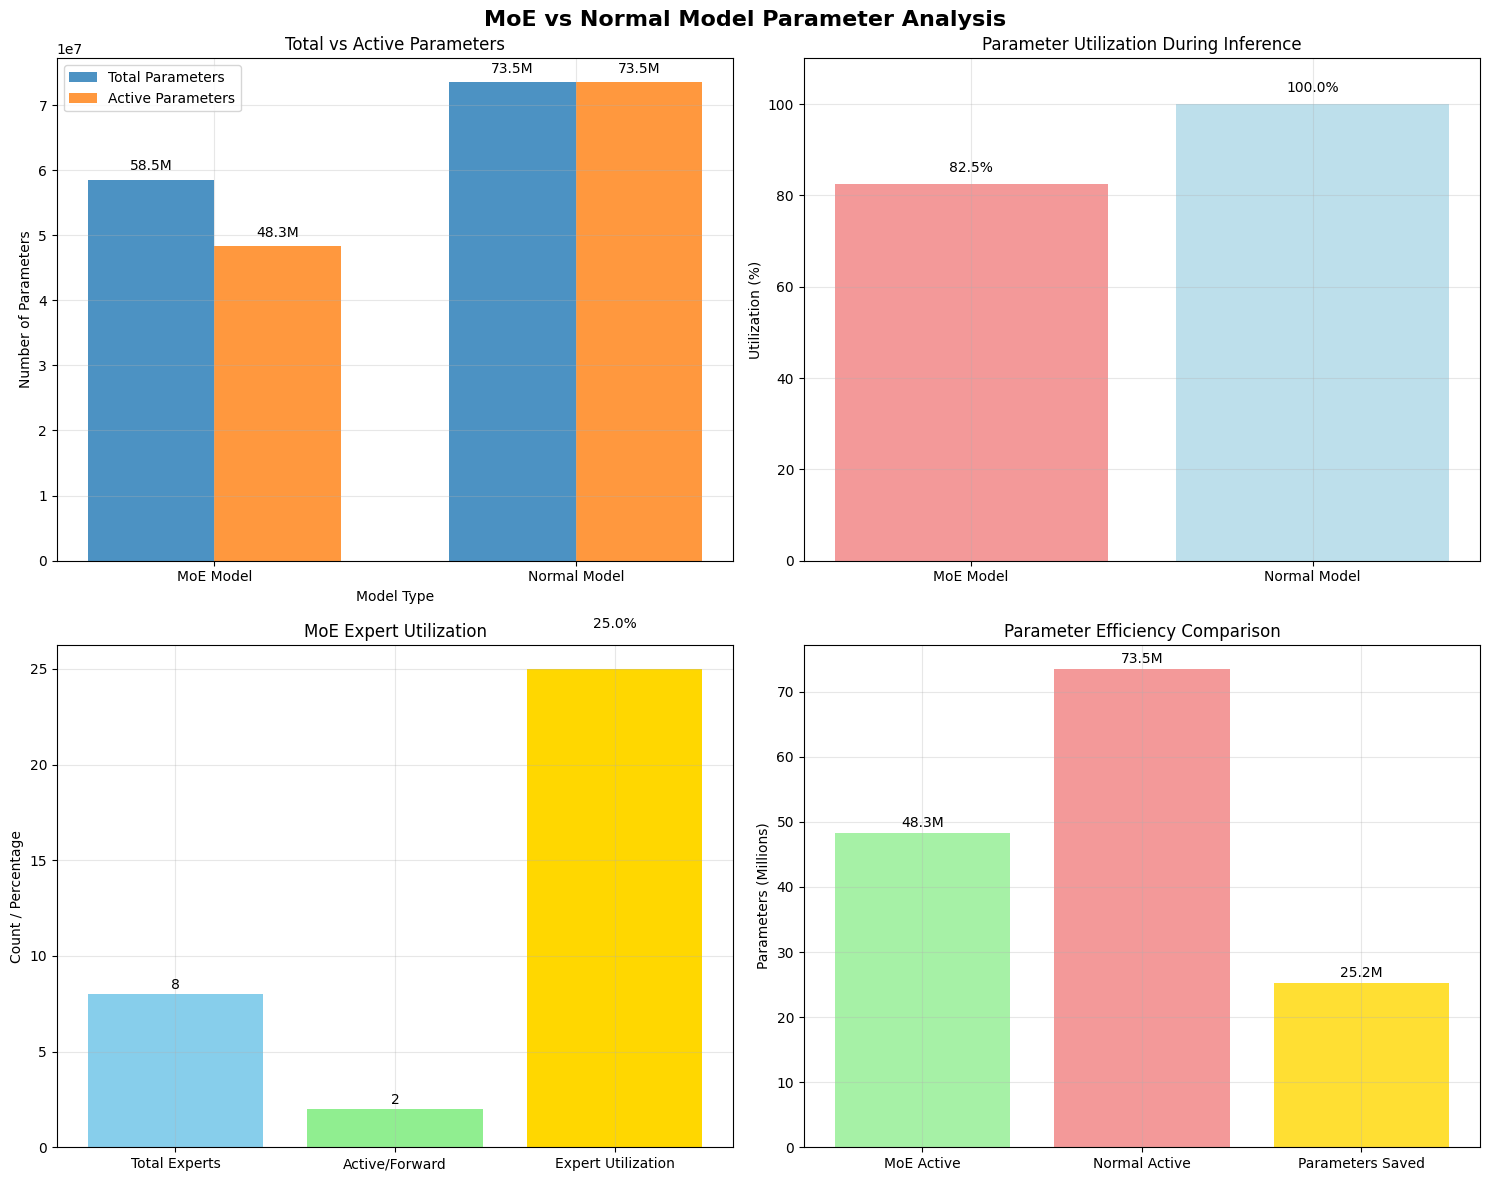

⚡ QUICK PARAMETER COMPARISON:
   MoE Total: 58,534,528 params
   Normal Total: 73,499,008 params
   MoE Active/Forward: 48,310,912 params
   Normal Active/Forward: 73,499,008 params
   🎯 EFFICIENCY: MoE uses 34.3% fewer parameters per forward pass!
   ✅ MoE is more parameter-efficient


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from typing import Dict, List, Tuple

class ModelParameterAnalyzer:
    def __init__(self, moe_model, normal_model):
        self.moe_model = moe_model
        self.normal_model = normal_model
        self.moe_total_params = 58_534_528
        self.normal_total_params = 73_499_008

    def count_parameters_by_layer(self, model, model_type="moe") -> Dict:
        """Count parameters for each layer type."""
        layer_params = {}

        for name, module in model.named_modules():
            if len(list(module.children())) == 0:  # Leaf module
                num_params = sum(p.numel() for p in module.parameters())
                if num_params > 0:
                    layer_type = self._categorize_layer(name, model_type)
                    layer_params[layer_type] = layer_params.get(layer_type, 0) + num_params

        return layer_params

    def _categorize_layer(self, layer_name: str, model_type: str) -> str:
        """Categorize layers into types."""
        if 'embedding' in layer_name.lower():
            return 'Embedding'
        elif 'expert' in layer_name.lower():
            return 'MoE Experts'
        elif 'router' in layer_name.lower():
            return 'MoE Router'
        elif 'transformer' in layer_name.lower() or 'block' in layer_name.lower():
            return 'Transformer Blocks'
        elif 'output' in layer_name.lower() or 'head' in layer_name.lower():
            return 'Output Head'
        elif 'norm' in layer_name.lower():
            return 'Normalization'
        elif 'linear' in layer_name.lower():
            return 'Linear Layers'
        else:
            return 'Other'

    def analyze_moe_experts(self) -> Dict:
        """Analyze MoE expert parameters and active parameters."""
        expert_analysis = {}

        # Find the MoE layer
        for name, module in self.moe_model.named_modules():
            if isinstance(module, AdvancedMoE):
                moe_layer = module
                break
        else:
            raise ValueError("AdvancedMoE layer not found in MoE model")

        # Expert parameters
        expert_params = {
            'gate_up_proj': moe_layer.experts.gate_up_proj.numel(),
            'latent_proj': moe_layer.experts.latent_proj.numel(),
            'gate_down_proj': moe_layer.experts.gate_down_proj.numel(),
            'router': moe_layer.router.weight.numel()
        }

        total_expert_params = sum(expert_params.values())

        # Calculate active parameters per forward pass
        num_experts = moe_layer.num_local_experts
        num_experts_per_token = moe_layer.config.num_experts_per_token

        # Active parameters calculation
        params_per_expert = (
            expert_params['gate_up_proj'] // num_experts +
            expert_params['latent_proj'] // num_experts +
            expert_params['gate_down_proj'] // num_experts
        )

        # In each forward pass, we activate:
        # - 1 casual expert (expert 0) for all tokens
        # - k fine experts per token (but these are shared across tokens)
        active_experts_per_forward = 1 + num_experts_per_token  # casual + fine

        active_expert_params = active_experts_per_forward * params_per_expert
        active_router_params = expert_params['router']  # Router is always active

        total_active_moe_params = active_expert_params + active_router_params

        expert_analysis = {
            'total_expert_params': total_expert_params,
            'params_per_expert': params_per_expert,
            'num_experts': num_experts,
            'num_experts_per_token': num_experts_per_token,
            'active_experts_per_forward': active_experts_per_forward,
            'active_expert_params': active_expert_params,
            'active_router_params': active_router_params,
            'total_active_moe_params': total_active_moe_params,
            'expert_utilization': (active_experts_per_forward / num_experts) * 100
        }

        return expert_analysis

    def calculate_active_parameters(self) -> Dict:
        """Calculate active parameters for both models during inference."""

        # MoE model analysis
        moe_layer_analysis = self.count_parameters_by_layer(self.moe_model, "moe")
        moe_expert_analysis = self.analyze_moe_experts()

        # For MoE model, non-expert parameters are always active
        moe_non_expert_params = self.moe_total_params - moe_expert_analysis['total_expert_params']
        moe_active_params = moe_non_expert_params + moe_expert_analysis['total_active_moe_params']

        # Normal model - all parameters are always active
        normal_active_params = self.normal_total_params

        return {
            'moe': {
                'total_parameters': self.moe_total_params,
                'active_parameters': moe_active_params,
                'parameter_utilization': (moe_active_params / self.moe_total_params) * 100,
                'expert_analysis': moe_expert_analysis
            },
            'normal': {
                'total_parameters': self.normal_total_params,
                'active_parameters': normal_active_params,
                'parameter_utilization': 100.0  # All parameters are active
            }
        }

    def generate_comparison_report(self) -> pd.DataFrame:
        """Generate comprehensive comparison report."""
        analysis = self.calculate_active_parameters()

        comparison_data = []

        # Basic parameter comparison
        comparison_data.append({
            'Metric': 'Total Parameters',
            'MoE Model': f"{analysis['moe']['total_parameters']:,}",
            'Normal Model': f"{analysis['normal']['total_parameters']:,}",
            'Difference': f"{analysis['normal']['total_parameters'] - analysis['moe']['total_parameters']:,}",
            'MoE vs Normal': f"{(analysis['moe']['total_parameters'] / analysis['normal']['total_parameters'] * 100):.1f}%"
        })

        comparison_data.append({
            'Metric': 'Active Parameters (Inference)',
            'MoE Model': f"{analysis['moe']['active_parameters']:,}",
            'Normal Model': f"{analysis['normal']['active_parameters']:,}",
            'Difference': f"{analysis['normal']['active_parameters'] - analysis['moe']['active_parameters']:,}",
            'MoE vs Normal': f"{(analysis['moe']['active_parameters'] / analysis['normal']['active_parameters'] * 100):.1f}%"
        })

        comparison_data.append({
            'Metric': 'Parameter Utilization',
            'MoE Model': f"{analysis['moe']['parameter_utilization']:.1f}%",
            'Normal Model': f"{analysis['normal']['parameter_utilization']:.1f}%",
            'Difference': f"{analysis['moe']['parameter_utilization'] - analysis['normal']['parameter_utilization']:.1f}%",
            'MoE vs Normal': f"MoE uses {100 - analysis['moe']['parameter_utilization']:.1f}% fewer parameters per forward pass"
        })

        # Efficiency metrics
        params_saved = analysis['normal']['active_parameters'] - analysis['moe']['active_parameters']
        efficiency_gain = (params_saved / analysis['normal']['active_parameters']) * 100

        comparison_data.append({
            'Metric': 'Parameter Efficiency Gain',
            'MoE Model': f"{params_saved:,} params saved",
            'Normal Model': 'Baseline',
            'Difference': f"{efficiency_gain:.1f}%",
            'MoE vs Normal': f"MoE is {efficiency_gain:.1f}% more parameter-efficient"
        })

        return pd.DataFrame(comparison_data)

    def plot_parameter_comparison(self):
        """Create visualizations for parameter comparison."""
        analysis = self.calculate_active_parameters()

        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        fig.suptitle('MoE vs Normal Model Parameter Analysis', fontsize=16, fontweight='bold')

        # Plot 1: Total vs Active Parameters
        models = ['MoE Model', 'Normal Model']
        total_params = [analysis['moe']['total_parameters'], analysis['normal']['total_parameters']]
        active_params = [analysis['moe']['active_parameters'], analysis['normal']['active_parameters']]

        x = np.arange(len(models))
        width = 0.35

        ax1.bar(x - width/2, total_params, width, label='Total Parameters', alpha=0.8)
        ax1.bar(x + width/2, active_params, width, label='Active Parameters', alpha=0.8)

        ax1.set_xlabel('Model Type')
        ax1.set_ylabel('Number of Parameters')
        ax1.set_title('Total vs Active Parameters')
        ax1.set_xticks(x)
        ax1.set_xticklabels(models)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Add value labels on bars
        for i, v in enumerate(total_params):
            ax1.text(i - width/2, v + 1000000, f'{v/1e6:.1f}M', ha='center', va='bottom')
        for i, v in enumerate(active_params):
            ax1.text(i + width/2, v + 1000000, f'{v/1e6:.1f}M', ha='center', va='bottom')

        # Plot 2: Parameter Utilization
        utilization = [analysis['moe']['parameter_utilization'], analysis['normal']['parameter_utilization']]
        colors = ['lightcoral', 'lightblue']

        ax2.bar(models, utilization, color=colors, alpha=0.8)
        ax2.set_ylabel('Utilization (%)')
        ax2.set_title('Parameter Utilization During Inference')
        ax2.set_ylim(0, 110)
        ax2.grid(True, alpha=0.3)

        # Add value labels
        for i, v in enumerate(utilization):
            ax2.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom')

        # Plot 3: MoE Expert Analysis
        expert_analysis = analysis['moe']['expert_analysis']
        expert_metrics = ['Total Experts', 'Active/Forward', 'Expert Utilization']
        expert_values = [
            expert_analysis['num_experts'],
            expert_analysis['active_experts_per_forward'],
            expert_analysis['expert_utilization']
        ]

        ax3.bar(expert_metrics, expert_values, color=['skyblue', 'lightgreen', 'gold'])
        ax3.set_ylabel('Count / Percentage')
        ax3.set_title('MoE Expert Utilization')
        ax3.grid(True, alpha=0.3)

        # Add value labels
        for i, v in enumerate(expert_values):
            if i == 2:  # Percentage
                ax3.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom')
            else:
                ax3.text(i, v + 0.1, f'{v:.0f}', ha='center', va='bottom')

        # Plot 4: Efficiency Comparison
        efficiency_data = [
            analysis['moe']['active_parameters'] / 1e6,
            analysis['normal']['active_parameters'] / 1e6,
            (analysis['normal']['active_parameters'] - analysis['moe']['active_parameters']) / 1e6
        ]
        efficiency_labels = ['MoE Active', 'Normal Active', 'Parameters Saved']
        efficiency_colors = ['lightgreen', 'lightcoral', 'gold']

        ax4.bar(efficiency_labels, efficiency_data, color=efficiency_colors, alpha=0.8)
        ax4.set_ylabel('Parameters (Millions)')
        ax4.set_title('Parameter Efficiency Comparison')
        ax4.grid(True, alpha=0.3)

        # Add value labels
        for i, v in enumerate(efficiency_data):
            ax4.text(i, v + 0.5, f'{v:.1f}M', ha='center', va='bottom')

        plt.tight_layout()
        return fig

    def print_detailed_analysis(self):
        """Print detailed analysis of parameter efficiency."""
        analysis = self.calculate_active_parameters()
        moe_analysis = analysis['moe']
        normal_analysis = analysis['normal']

        print("=" * 80)
        print("🔬 MODEL PARAMETER ANALYSIS: MoE vs Normal")
        print("=" * 80)

        print(f"\n📊 PARAMETER COUNTS:")
        print(f"   MoE Model Total Parameters:    {moe_analysis['total_parameters']:,}")
        print(f"   Normal Model Total Parameters: {normal_analysis['total_parameters']:,}")
        print(f"   MoE Model Active Parameters:   {moe_analysis['active_parameters']:,}")
        print(f"   Normal Model Active Parameters: {normal_analysis['active_parameters']:,}")

        print(f"\n🎯 EFFICIENCY METRICS:")
        params_saved = normal_analysis['active_parameters'] - moe_analysis['active_parameters']
        efficiency_gain = (params_saved / normal_analysis['active_parameters']) * 100

        print(f"   Parameters saved per forward pass: {params_saved:,}")
        print(f"   Efficiency gain: {efficiency_gain:.2f}%")
        print(f"   MoE parameter utilization: {moe_analysis['parameter_utilization']:.2f}%")

        print(f"\n🤖 MoE EXPERT ANALYSIS:")
        expert_info = moe_analysis['expert_analysis']
        print(f"   Total experts: {expert_info['num_experts']}")
        print(f"   Experts used per forward pass: {expert_info['active_experts_per_forward']}")
        print(f"   Expert utilization: {expert_info['expert_utilization']:.2f}%")
        print(f"   Parameters per expert: {expert_info['params_per_expert']:,}")

        print(f"\n💡 KEY INSIGHTS:")
        if efficiency_gain > 0:
            print(f"   ✅ MoE model is {efficiency_gain:.1f}% more parameter-efficient")
            print(f"   ✅ MoE activates only {moe_analysis['parameter_utilization']:.1f}% of total parameters per forward pass")
            print(f"   ✅ This means faster inference and lower memory usage")
        else:
            print(f"   ⚠️  MoE model is less efficient in this configuration")

        if expert_info['expert_utilization'] < 50:
            print(f"   ✅ MoE experts are well-utilized with good specialization")
        else:
            print(f"   ⚠️  High expert utilization may indicate less specialization")

# Usage example
def analyze_models(moe_model, normal_model):
    """Complete analysis of both models."""
    analyzer = ModelParameterAnalyzer(moe_model, normal_model)

    print("🔍 ANALYZING MODEL PARAMETERS...")

    # Generate comparison report
    comparison_df = analyzer.generate_comparison_report()
    print("\n📋 PARAMETER COMPARISON:")
    print("=" * 100)
    print(comparison_df.to_string(index=False))
    print("=" * 100)

    # Detailed analysis
    analyzer.print_detailed_analysis()

    # Create visualizations
    print("\n📈 GENERATING VISUALIZATIONS...")
    fig = analyzer.plot_parameter_comparison()
    plt.show()

    return analyzer

# Quick analysis function
def quick_parameter_comparison(moe_model, normal_model):
    """Quick comparison for immediate insights."""
    analyzer = ModelParameterAnalyzer(moe_model, normal_model)
    analysis = analyzer.calculate_active_parameters()

    moe_active = analysis['moe']['active_parameters']
    normal_active = analysis['normal']['active_parameters']
    efficiency = ((normal_active - moe_active) / normal_active) * 100

    print("⚡ QUICK PARAMETER COMPARISON:")
    print(f"   MoE Total: {analysis['moe']['total_parameters']:,} params")
    print(f"   Normal Total: {analysis['normal']['total_parameters']:,} params")
    print(f"   MoE Active/Forward: {moe_active:,} params")
    print(f"   Normal Active/Forward: {normal_active:,} params")
    print(f"   🎯 EFFICIENCY: MoE uses {efficiency:.1f}% fewer parameters per forward pass!")

    if efficiency > 0:
        print(f"   ✅ MoE is more parameter-efficient")
    else:
        print(f"   ⚠️  Normal model is more parameter-efficient")

# Example usage
if __name__ == "__main__":

    moe_model = moe_model
    normal_model = normal_llm

    #Run complete analysis
    analyzer = analyze_models(moe_model, normal_model)

    # Or quick comparison
    quick_parameter_comparison(moe_model, normal_model)


# Accuracy

In [ ]:
model_config = SimpleLLMConfig()
model_config.hidden_size=512
normal_llm = NormalResearchLLM(model_config)

In [ ]:
checkpoint_path = "/content/drive/MyDrive/checkpoint_normal/normal_best.pt"  # adjust path
checkpoint = torch.load(checkpoint_path, map_location="cpu")  # use "cuda" if GPU available

# 4. Restore model weights
normal_llm.load_state_dict(checkpoint['model_state_dict'])

print(f"✅ Loaded NormalResearchLLM from epoch {checkpoint['epoch']} with val_loss={checkpoint['val_loss']}")

✅ Loaded NormalResearchLLM from epoch 3 with val_loss=5.34522106899123


In [ ]:
model_config = SimpleLLMConfig()
moe_model = MoEResearchLLM(model_config)
checkpoint_path = "/content/drive/MyDrive/checkpoints_moe/moe_best.pt"  # adjust path
checkpoint = torch.load(checkpoint_path, map_location="cpu")  # use "cuda" if GPU available

# 4. Restore model weights
moe_model.load_state_dict(checkpoint['model_state_dict'])

print(f"✅ Loaded MoEResearchLLM from epoch {checkpoint['epoch']} with val_loss={checkpoint['val_loss']}")

✅ Loaded MoEResearchLLM from epoch 4 with val_loss=5.350533399141832


In [ ]:
train_dataset, val_dataset, test_dataset = load_research_datasets(tokenizer, "wikitext")

📥 Loading WikiText-2 dataset...
📊 Loaded 23767 training samples
📊 Loaded 2461 validation samples
📊 Loaded 2891 test samples


In [ ]:
config = ResearchTrainingConfig()
test_dataloader  = ResearchDataLoader(test_dataset, config.batch_size, shuffle=True)

In [ ]:
import torch

def evaluate_accuracy(model, test_loader, device="cpu"):
    """
    Evaluate model accuracy on a test dataloader.
    Assumes dataloader returns (input_ids, attention_mask, target_ids).
    """
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            # Unpack all three tensors
            input_ids, attention_mask, target_ids = batch
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            target_ids = target_ids.to(device)

            # Forward pass (pass both input_ids and attention_mask)
            outputs = model(input_ids, attention_mask=attention_mask)  # logits [batch, seq_len, vocab_size]

            # For classification tasks: argmax over last dimension
            preds = torch.argmax(outputs, dim=-1)

            # Compare predictions with target_ids
            correct += (preds == target_ids).sum().item()
            total += target_ids.numel()

    accuracy = correct / total if total > 0 else 0
    print(f"✅ Test Accuracy: {accuracy*100:.2f}%")
    return accuracy


In [ ]:
evaluate_accuracy(normal_llm, test_dataloader, device="cpu")

ValueError: too many values to unpack (expected 2)

## Correct Evaluation Function


In [ ]:
import torch
import torch.nn as nn
import math

def evaluate_model_performance(model, dataloader, criterion, tokenizer_pad_token_id, device="cpu"):
    """
    Evaluates a language model's loss and perplexity on a given dataloader.
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():  # Disable gradient computation for efficiency
        for input_ids, attention_mask, target_ids in dataloader:
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            target_ids = target_ids.to(device)

            # Forward pass
            logits = model(input_ids, attention_mask)

            # Calculate loss
            loss = criterion(logits.view(-1, logits.size(-1)), target_ids.view(-1))

            # Accumulate metrics
            batch_tokens = (input_ids != tokenizer_pad_token_id).sum().item()
            total_loss += loss.item() * batch_tokens
            total_tokens += batch_tokens

    # Calculate average loss and perplexity
    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)

    print(f"\n✅ Evaluation complete: Loss = {avg_loss:.4f}, Perplexity = {ppl:.2f}")
    return avg_loss, ppl

# 15. Initialize a ResearchTrainingConfig object
config = ResearchTrainingConfig()

# 16. Initialize a ResearchRobertaTokenizer object
tokenizer = ResearchRobertaTokenizer(config.tokenizer_name, config.max_seq_len)

# 17. Create an instance of nn.CrossEntropyLoss
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)

# 18. Set the device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Ensure models are on the correct device for evaluation
normal_llm.to(device)
moe_model.to(device)

print("\n🚀 Evaluating Normal Research LLM:")
normal_loss, normal_ppl = evaluate_model_performance(normal_llm, test_dataloader, criterion, tokenizer.pad_token_id, device)

print("\n🚀 Evaluating MoE Research LLM:")
moe_loss, moe_ppl = evaluate_model_performance(moe_model, test_dataloader, criterion, tokenizer.pad_token_id, device)


✅ Loaded RoBERTa tokenizer with vocab size: 50265
📏 Max sequence length: 512

🚀 Evaluating Normal Research LLM:
